# Importing all required libraries for supervised learning

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [7]:


# Task 1: Data Loading and Inspection
df = pd.read_csv('D:\\Data\\Training - Masai - BA with Gen AI\\Module 4 - ML\\ml-assessment-adhik-kadam\\data\\q1_heart_disease.csv')
print("Dataset Shape:", df.shape)
print("\nData Types:\n", df.dtypes)
print("\nMissing Values Count:\n", df.isnull().sum())
print("\nFirst 5 rows:")
print(df.head())

Dataset Shape: (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing Values Count:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 rows:
   age  sex  chest_pain_type  resting_bp  cholesterol  fasting_bs  \
0   68    0  atypical_angina       142.0        399.0           0   
1   58    1      non_anginal       163.0        310.0           1   
2   44    1      non_anginal       128.0        175.0           0   
3   72    1     asymptomatic   

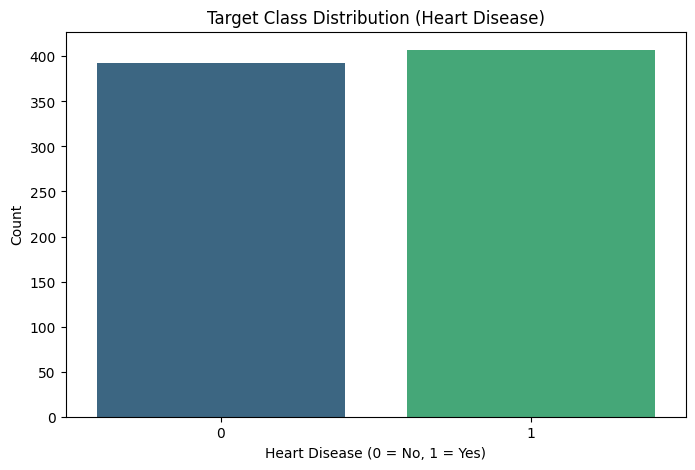

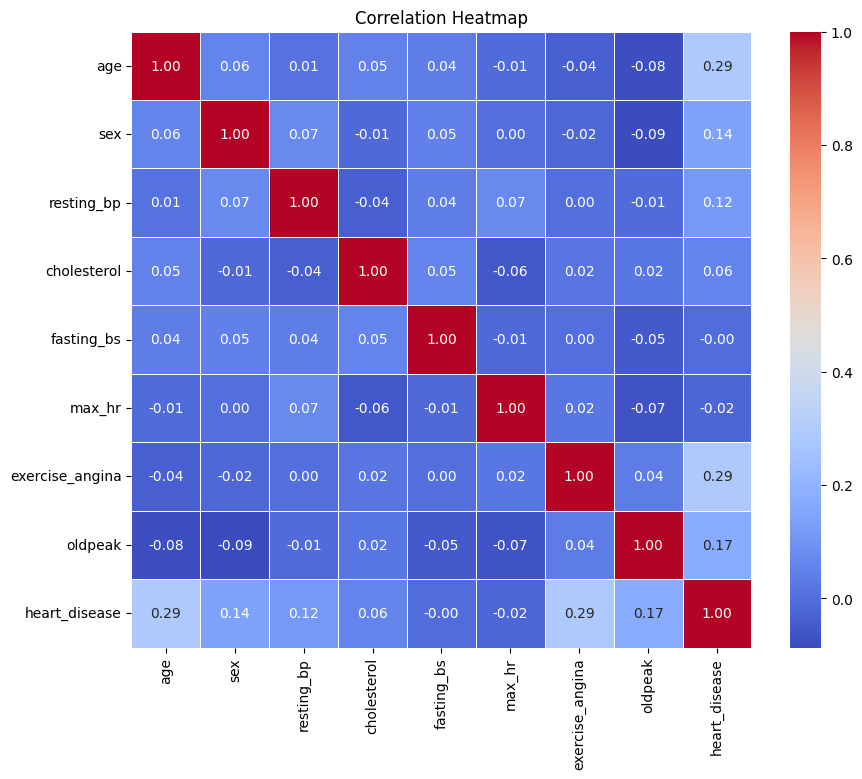

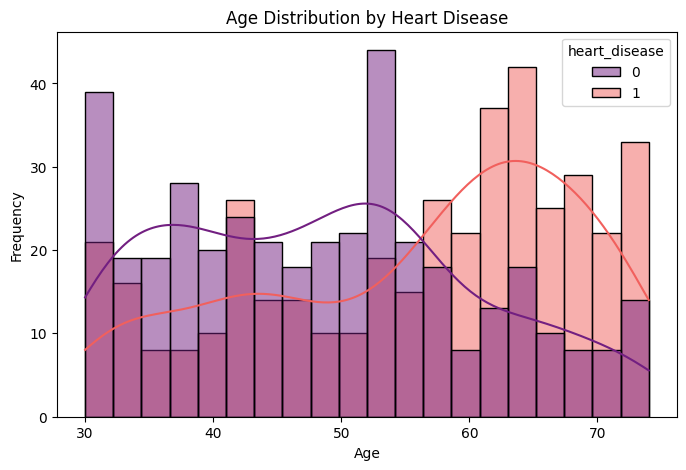

In [8]:
# Task 2: Exploratory Data Analysis (EDA)

# 1. Target Class Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='heart_disease', hue='heart_disease', palette='viridis', legend=False)
plt.title('Target Class Distribution (Heart Disease)')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.savefig('target_distribution.png')

# 2. Correlation Heatmap
# Select only numeric columns for correlation
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png')

# 3. Age Distribution by Heart Disease
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='heart_disease', kde=True, bins=20, palette='magma')
plt.title('Age Distribution by Heart Disease')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.savefig('age_distribution.png')

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Task 3: Data Preprocessing

# Features and Target
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

# Identify column types
numeric_features = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']
binary_features = ['sex', 'fasting_bs', 'exercise_angina']
categorical_features = ['chest_pain_type', 'resting_ecg', 'st_slope']

# Preprocessing for numerical data: Median imputation and Scaling
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical data: One-hot encoding
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('bin', 'passthrough', binary_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Get feature names for transparency (optional but good)
# Note: OneHotEncoder feature names can be complex to retrieve in old versions, but let's try.
try:
    cat_feature_names = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
    all_feature_names = numeric_features + binary_features + list(cat_feature_names)
except:
    all_feature_names = None

print("Preprocessing complete.")
print("Training set shape:", X_train_processed.shape)
print("Test set shape:", X_test_processed.shape)

# Task 4: Model Training

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Task 5: Model Evaluation
results = {}

for name, model in models.items():
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)
    
    print(f"\n--- {name} ---")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    results[name] = {
        'model': model,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': classification_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score']
    }

Preprocessing complete.
Training set shape: (640, 18)
Test set shape: (160, 18)

--- Decision Tree ---
Confusion Matrix:
[[57 22]
 [21 60]]

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.72      0.73        79
           1       0.73      0.74      0.74        81

    accuracy                           0.73       160
   macro avg       0.73      0.73      0.73       160
weighted avg       0.73      0.73      0.73       160


--- Random Forest ---
Confusion Matrix:
[[64 15]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.81      0.81        79
           1       0.81      0.81      0.81        81

    accuracy                           0.81       160
   macro avg       0.81      0.81      0.81       160
weighted avg       0.81      0.81      0.81       160


--- Gradient Boosting ---
Confusion Matrix:
[[61 18]
 [18 63]]

Classification Report:
          

In [10]:
# Task 6: Hyperparameter Tuning for the Best Model (Random Forest)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_base = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)

grid_search.fit(X_train_processed, y_train)

best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test_processed)

print("\nBest Parameters found by GridSearchCV:")
print(grid_search.best_params_)

print("\n--- Tuned Random Forest Performance ---")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

# Comparison
baseline_f1 = results['Random Forest']['f1']
tuned_f1 = classification_report(y_test, y_pred_tuned, output_dict=True)['weighted avg']['f1-score']

print(f"\nBaseline Weighted F1-score: {baseline_f1:.4f}")
print(f"Tuned Weighted F1-score: {tuned_f1:.4f}")


Best Parameters found by GridSearchCV:
{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 50}

--- Tuned Random Forest Performance ---
Confusion Matrix:
[[61 18]
 [14 67]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.77      0.79        79
           1       0.79      0.83      0.81        81

    accuracy                           0.80       160
   macro avg       0.80      0.80      0.80       160
weighted avg       0.80      0.80      0.80       160


Baseline Weighted F1-score: 0.8125
Tuned Weighted F1-score: 0.7998
